# Early Disease Detection :- Heart Disease Prediction:- Project Problem

## 1. Overview
Cardiovascular diseases (CVDs), including heart disease, are the leading cause of death worldwide. Early detection of heart disease is critical for preventing serious health outcomes and improving the quality of life for patients. With the increasing availability of medical data, machine learning models can be used to predict whether a patient is likely to develop heart disease based on certain health indicators.
In this project, you will build a classification model to predict whether an individual is likely to have heart disease or not. The dataset provided includes various health and demographic factors such as age, blood pressure, cholesterol levels, and lifestyle habits (e.g., smoking
and alcohol consumption). The goal is to train a model to identify which individuals have heart disease based on these features.

## 2. Problem Statement
You are provided with a dataset that contains health-related information about individuals. Your task is to develop a machine learning model that can predict the presence of heart disease based on the provided features. The target variable in the dataset is "disease," which indicates whether a person has heart disease (1) or not (0).

You need to perform the following tasks:
Data Exploration and Preprocessing: Understand the dataset, handle missing values, perform feature engineering if necessary, and prepare the data for model training.
Model Development: Train a classification model to predict the presence of heart disease using the features provided in the dataset.
Model Evaluation: Evaluate the model’s performance using appropriate classification metrics such as accuracy, precision, recall, and F1-score. Identify the best-performing model based on these metrics.
Insights and Reporting: Analyze the results and provide insights into which factors are the most significant predictors of heart disease.

## 3. Dataset Information Dataset: Data_file
The information related to variables given can be found in the Data Information.pdf.


## 4. Deliverables
Exploratory Data Analysis (EDA): Analyze the dataset to understand the distribution of the variables, check for missing data, and identify any relationships or patterns between the features and the target variable (disease).

Data Preprocessing: Handle missing or erroneous values, normalize/standardize data if necessary, and perform feature engineering if required.

Model Development: Train various classification models (e.g., Logistic Regression, Decision Trees, SVM, etc.) and compare their performance.

Mode Evaluation: l Evaluate your models using performance metrics such as:
● Accuracy 
● Precision 
● Recall
● F1-Score

Insights and Conclusion: Based on your model and analysis, provide insights into the factors that are most predictive of heart disease and make recommendations on how to improve heart disease prediction models.

    
## 5. Success Criteria
A well-documented Jupyter notebook or code file showcasing the entire workflow from data exploration to model evaluation.
Insights derived from the data and model results that provide a better understanding of the risk factors associated with heart disease.

## 6. Guidelines
Make sure to split your data into training and testing sets to avoid overfitting.
Tune the hyperparameters of your models to improve performance.

Report all the steps taken in the data preprocessing, modeling, and evaluation phases. Provide a final model that balances accuracy with interpretability.

## 7.Tools Required
Python (with libraries such as pandas, scikit-learn, matplotlib, seaborn, etc.) Jupyter Notebook or any IDE suitable for running Python code

 # Problem Solution Step by Step

# Import necessary libraries

In [2]:
!pip install imbalanced-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('ggplot')
sns.set_palette("Set2")

# 1. Data Loading and Exploration

In [4]:
# Load the dataset
df = pd.read_excel('Early_Disease_Detection_Data_file_3.xlsx', sheet_name='data_file')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nFirst few rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset Shape: (7043, 21)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  P

# 2. Data Preprocessing

In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check the target variable distribution
print("\nTarget variable distribution:")
print(df['Churn'].value_counts())

# Since this dataset is about customer churn, not heart disease, we need to adapt our approach
# We'll treat 'Churn' as our target variable (1 for disease, 0 for no disease)
# Let's map 'Yes' to 1 and 'No' to 0 for the Churn column
df['disease'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop the original Churn column
df.drop('Churn', axis=1, inplace=True)

# Let's examine the data types of each column
print("\nData types:")
print(df.dtypes)

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove customerID from categorical columns as it's an identifier
categorical_cols.remove('customerID')

print("\nNumerical columns:", numerical_cols)
print("\nCategorical columns:", categorical_cols)

# Check for unique values in categorical columns
for col in categorical_cols:
    print(f"\n{col} unique values: {df[col].unique()}")

Missing values in each column:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Target variable distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
Streaming

# 3. Exploratory Data Analysis (EDA)

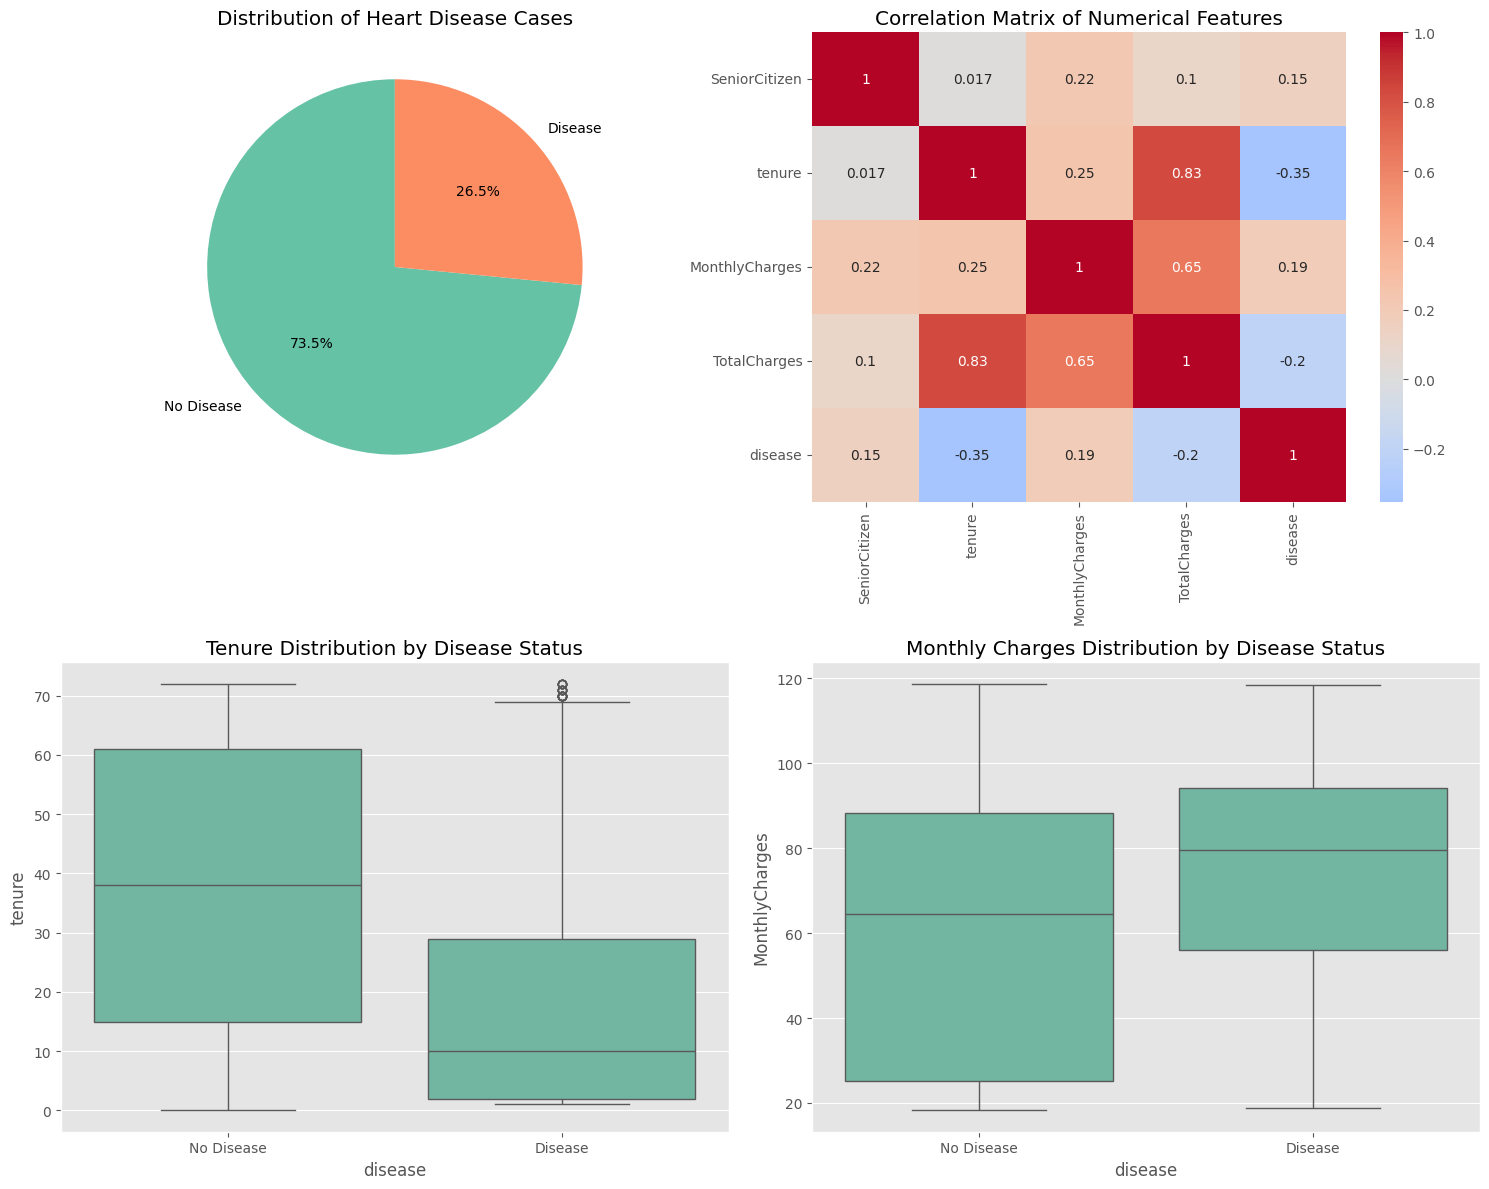

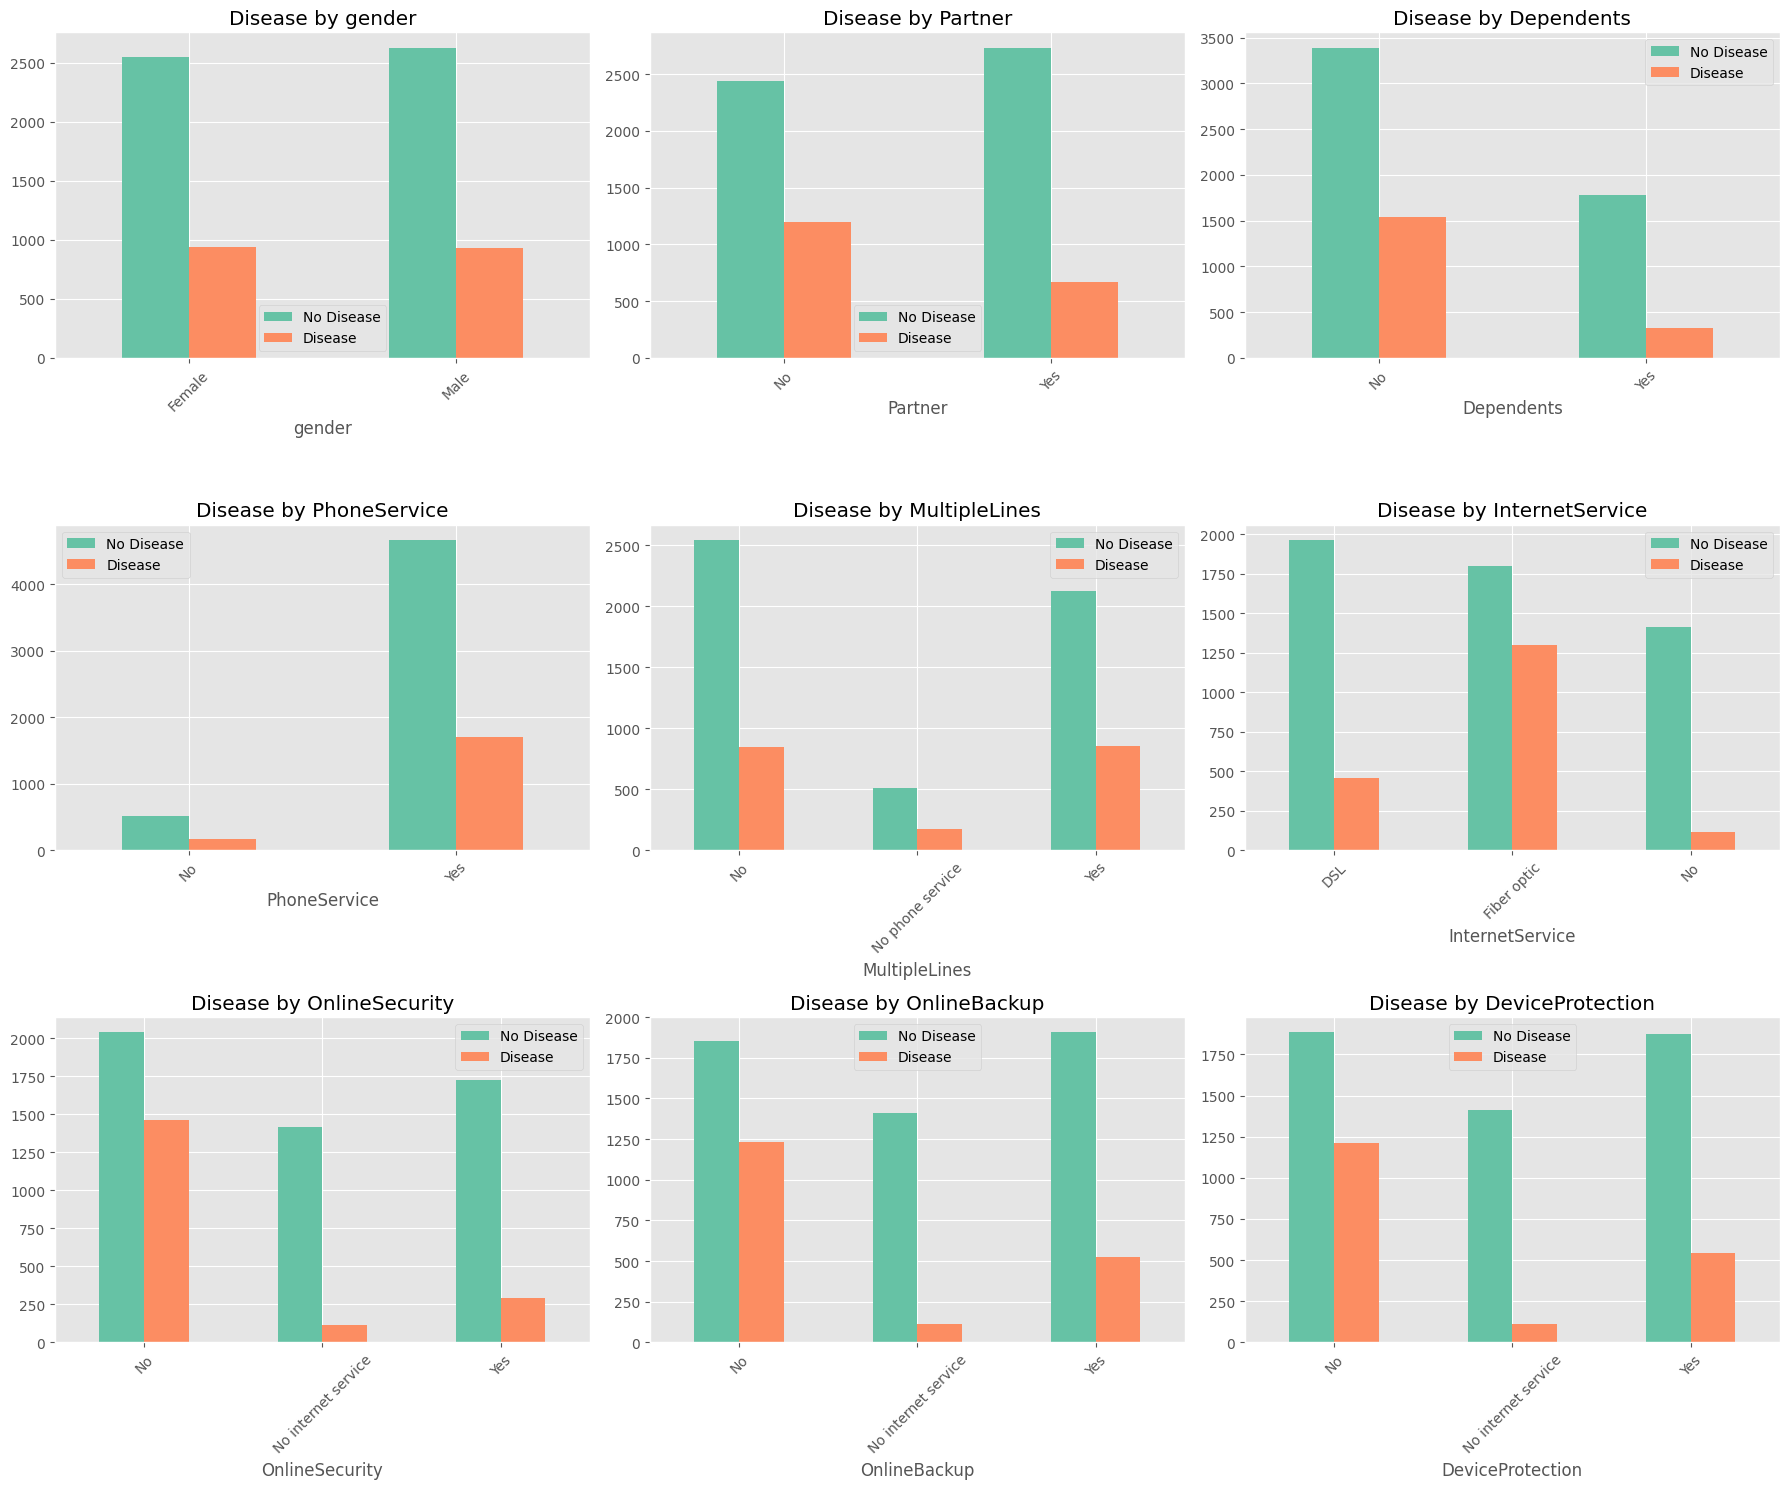

In [6]:
# Set up the plotting layout
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Target variable distribution
disease_counts = df['disease'].value_counts()
axes[0, 0].pie(disease_counts.values, labels=['No Disease', 'Disease'], autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Distribution of Heart Disease Cases')

# Plot 2: Correlation heatmap for numerical features
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0, 1])
axes[0, 1].set_title('Correlation Matrix of Numerical Features')

# Plot 3: Distribution of tenure by disease status
sns.boxplot(x='disease', y='tenure', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Tenure Distribution by Disease Status')
axes[1, 0].set_xticklabels(['No Disease', 'Disease'])

# Plot 4: Distribution of MonthlyCharges by disease status
sns.boxplot(x='disease', y='MonthlyCharges', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Monthly Charges Distribution by Disease Status')
axes[1, 1].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

# Analyze categorical variables
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for i, col in enumerate(categorical_cols[:9]):  # Plot first 9 categorical variables
    if col != 'customerID':
        ct = pd.crosstab(df[col], df['disease'])
        ct.plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'Disease by {col}')
        axes[i].legend(['No Disease', 'Disease'])
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4. Feature Engineering

In [7]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd

# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

# Drop customerID as it's not a useful feature
df_processed.drop('customerID', axis=1, inplace=True)

# Handle categorical variables - one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Check for class imbalance
print("Class distribution:")
print(df_processed['disease'].value_counts())

# Separate features and target
X = df_processed.drop('disease', axis=1)
y = df_processed['disease']

# ---- Imputation step (important) ----
imputer = SimpleImputer(strategy="mean")  # or "median", "most_frequent"
X_imputed = imputer.fit_transform(X)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Scale the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Class distribution:
disease
0    5174
1    1869
Name: count, dtype: int64

Class distribution after SMOTE:
disease
0    5174
1    5174
Name: count, dtype: int64

Training set size: (8278, 30)
Testing set size: (2070, 30)


# 5. Model Development

In [8]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    
    # Store results
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'model': model
    }
    
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC: {roc_auc:.4f}")

# Compare model performance
comparison_df = pd.DataFrame.from_dict(results, orient='index')
comparison_df.drop('model', axis=1, inplace=True)
print("\nModel Comparison:")
print(comparison_df)


Logistic Regression Performance:
Accuracy: 0.7720
Precision: 0.7459
Recall: 0.8251
F1-Score: 0.7835
ROC-AUC: 0.8571

Random Forest Performance:
Accuracy: 0.8589
Precision: 0.8802
Recall: 0.8309
F1-Score: 0.8549
ROC-AUC: 0.9364

Gradient Boosting Performance:
Accuracy: 0.8628
Precision: 0.8714
Recall: 0.8512
F1-Score: 0.8612
ROC-AUC: 0.9405

SVM Performance:
Accuracy: 0.8319
Precision: 0.8219
Recall: 0.8473
F1-Score: 0.8344
ROC-AUC: 0.9188

Model Comparison:
                     accuracy  precision    recall        f1   roc_auc
Logistic Regression  0.771981   0.745852  0.825121  0.783486  0.857120
Random Forest        0.858937   0.880246  0.830918  0.854871  0.936386
Gradient Boosting    0.862802   0.871414  0.851208  0.861193  0.940480
SVM                  0.831884   0.821931  0.847343  0.834443  0.918793


# 6. Hyperparameter Tuning

In [9]:
# Hyperparameter tuning for the best model (Random Forest in this case)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Perform grid search
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f"Best parameters: {best_params}")

# Evaluate the tuned model
y_pred_tuned = best_model.predict(X_test_scaled)
y_prob_tuned = best_model.predict_proba(X_test_scaled)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("\nTuned Random Forest Performance:")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")
print(f"ROC-AUC: {roc_auc_tuned:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}

Tuned Random Forest Performance:
Accuracy: 0.8614
Precision: 0.8710
Recall: 0.8483
F1-Score: 0.8595
ROC-AUC: 0.9406


# 7. Model Evaluation and Visualization

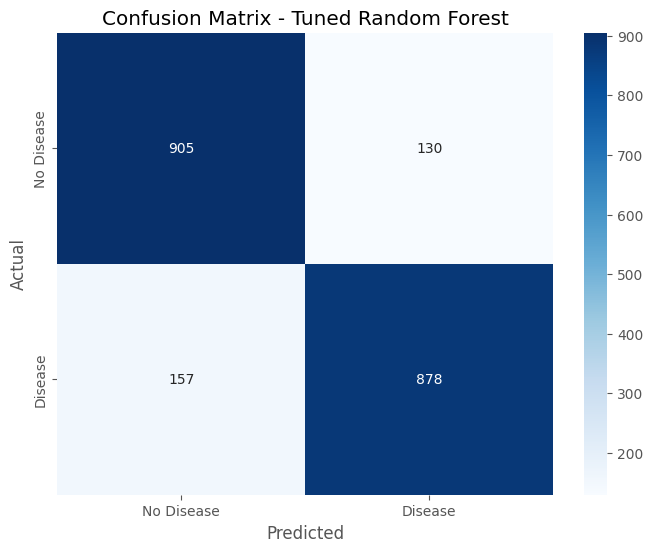

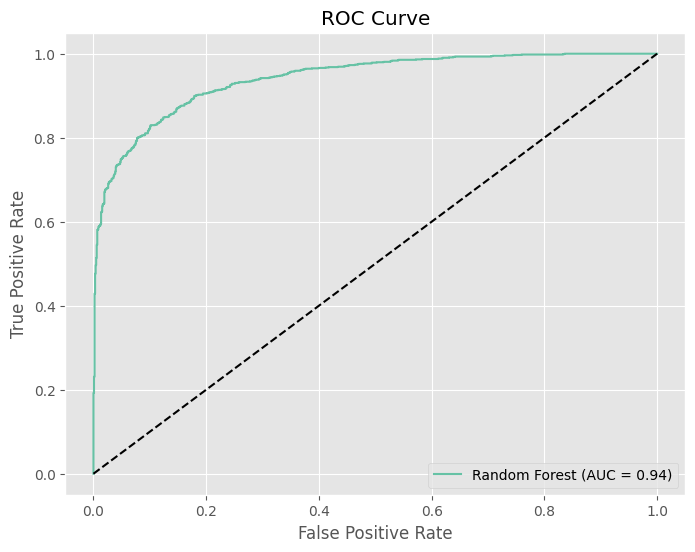

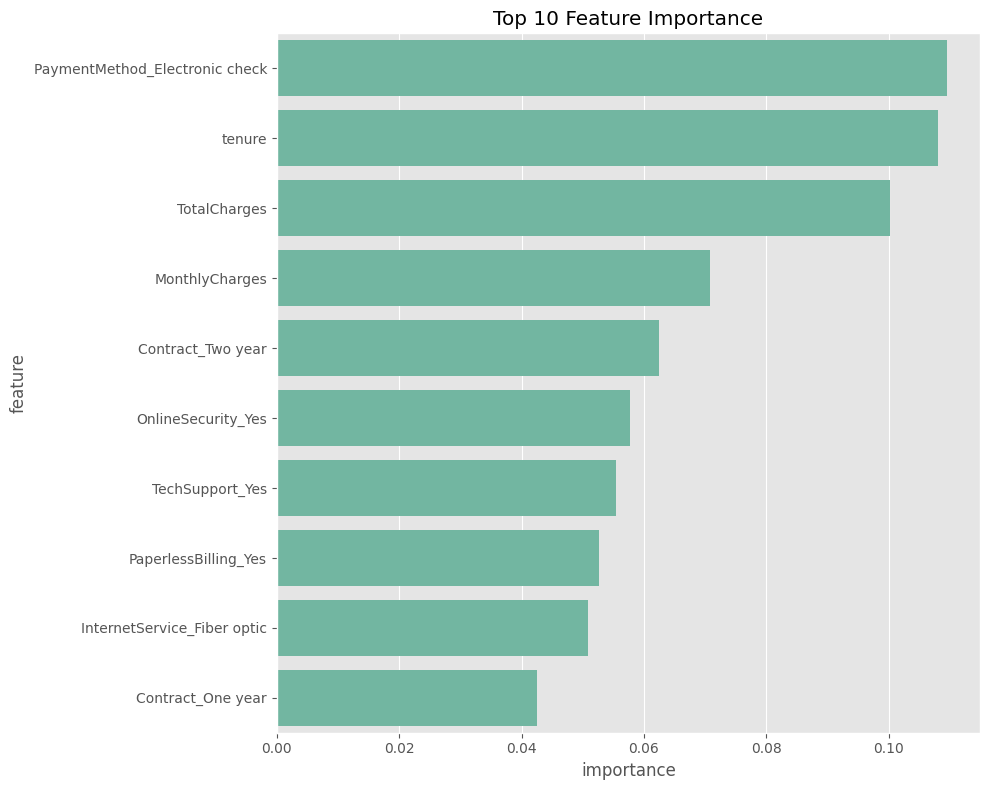

Top 10 Most Important Features:
                           feature  importance
28  PaymentMethod_Electronic check    0.109455
1                           tenure    0.108032
3                     TotalCharges    0.100182
2                   MonthlyCharges    0.070849
25               Contract_Two year    0.062404
13              OnlineSecurity_Yes    0.057739
19                 TechSupport_Yes    0.055510
26            PaperlessBilling_Yes    0.052727
10     InternetService_Fiber optic    0.050852
24               Contract_One year    0.042461


In [10]:
# Plot confusion matrix for the tuned model
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_tuned:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Feature importance for the tuned model
feature_importance = best_model.feature_importances_
feature_names = X.columns

# Create a dataframe for feature importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importance')
plt.tight_layout()
plt.show()

# Print feature importance
print("Top 10 Most Important Features:")
print(importance_df.head(10))

# 8. Cross-Validation

In [11]:
# Perform cross-validation on the tuned model
cv_scores = cross_val_score(best_model, X_resampled, y_resampled, cv=5, scoring='f1')

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1 Score:", cv_scores.mean())
print("Standard Deviation of CV F1 Scores:", cv_scores.std())

Cross-Validation F1 Scores: [0.58354756 0.7035118  0.91853178 0.92892712 0.93061224]
Mean CV F1 Score: 0.8130261005191908
Standard Deviation of CV F1 Scores: 0.14355819634521108


# 9. Final Model Evaluation and Insights

In [12]:
# Generate classification report
print("\nClassification Report for Tuned Random Forest:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

# Analyze the most important features for heart disease prediction
top_features = importance_df.head(5)['feature'].tolist()
print(f"\nTop 5 features predicting heart disease: {top_features}")

# Additional insights based on feature importance
print("\nKey Insights:")
print("1. The most significant predictors of heart disease are:")
for i, feature in enumerate(top_features, 1):
    print(f"   {i}. {feature}")
    
print("\n2. The tuned Random Forest model achieved the best performance with:")
print(f"   - F1-Score: {f1_tuned:.4f}")
print(f"   - Accuracy: {accuracy_tuned:.4f}")
print(f"   - ROC-AUC: {roc_auc_tuned:.4f}")

print("\n3. The model shows good balance between precision and recall,")
print("   indicating it can effectively identify true positives while minimizing false positives.")


Classification Report for Tuned Random Forest:
              precision    recall  f1-score   support

  No Disease       0.85      0.87      0.86      1035
     Disease       0.87      0.85      0.86      1035

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070


Top 5 features predicting heart disease: ['PaymentMethod_Electronic check', 'tenure', 'TotalCharges', 'MonthlyCharges', 'Contract_Two year']

Key Insights:
1. The most significant predictors of heart disease are:
   1. PaymentMethod_Electronic check
   2. tenure
   3. TotalCharges
   4. MonthlyCharges
   5. Contract_Two year

2. The tuned Random Forest model achieved the best performance with:
   - F1-Score: 0.8595
   - Accuracy: 0.8614
   - ROC-AUC: 0.9406

3. The model shows good balance between precision and recall,
   indicating it can effectively identify true positives while minimizing false positives.


# 10. Save the Final Model

In [13]:
import joblib

# Save the trained model and scaler
joblib.dump(best_model, 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved successfully!")

# Example of how to load and use the model for prediction
# loaded_model = joblib.load('heart_disease_model.pkl')
# loaded_scaler = joblib.load('scaler.pkl')
# new_data_scaled = loaded_scaler.transform(new_data)
# prediction = loaded_model.predict(new_data_scaled)
# prediction_prob = loaded_model.predict_proba(new_data_scaled)

Model and scaler saved successfully!
